<a href="https://colab.research.google.com/github/adithya-ashoks/deep-learning-practice/blob/main/Regularization_in_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [2]:
x,y = make_moons (100, noise=0.25, random_state = 2 )

<function matplotlib.pyplot.show(close=None, block=None)>

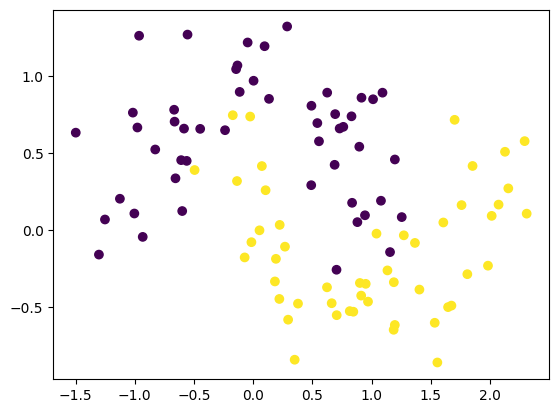

In [3]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show

In [4]:
model1 = Sequential()
model1.add(Dense(128, input_dim = 2, activation = 'relu'))
model1.add(Dense(128, activation = 'relu'))
model1.add(Dense(1, activation = 'sigmoid'))

model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate = 0.01)
model1.compile(loss = 'binary_crossentropy', optimizer = adam, metrics = ['accuracy'])
history1 = model1.fit(x,y, epochs =2000, validation_split=0.2, verbose =0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 856us/step


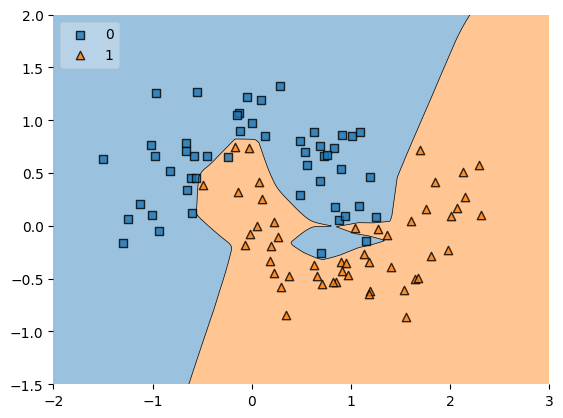

In [6]:
plot_decision_regions(x,y.astype('int'), clf=model1, legend = 2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

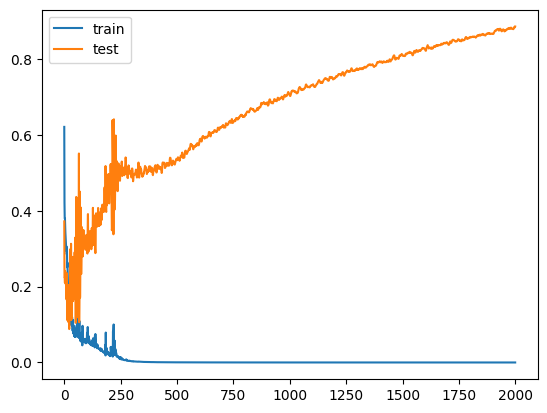

In [7]:
plt.plot(history1.history['loss'],label ='train')
plt.plot(history1.history['val_loss'],label = 'test')
plt.legend()

In [8]:
model2 = Sequential()

model2.add(Dense(128, input_dim = 2, activation = 'relu', kernel_regularizer = tensorflow.keras.regularizers.l2(0.05)))
model2.add(Dense(128, activation = 'relu',kernel_regularizer = tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(1, activation = 'sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = Adam(learning_rate = 0.01)
model2.compile(loss = 'binary_crossentropy', optimizer = adam, metrics = ['accuracy'])
history2 = model2.fit(x,y, epochs =2000, validation_split=0.2)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.5000 - loss: 4.1758 - val_accuracy: 0.8500 - val_loss: 2.7844
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7625 - loss: 2.4366 - val_accuracy: 0.9000 - val_loss: 1.5747
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8125 - loss: 1.4128 - val_accuracy: 0.9000 - val_loss: 0.9322
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8125 - loss: 0.8956 - val_accuracy: 0.9000 - val_loss: 0.6579
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8000 - loss: 0.6905 - val_accuracy: 0.9000 - val_loss: 0.5384
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8250 - loss: 0.6467 - val_accuracy: 0.9000 - val_loss: 0.5508
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8500 - loss: 0.6446 - val_accuracy: 0.9000 - val_loss: 0.5574
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8125 - loss: 0.6760 - val_accuracy: 0.9000 - v

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 801us/step


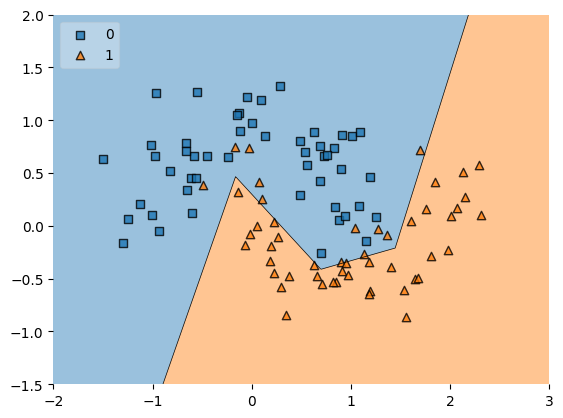

In [10]:
plot_decision_regions(x,y.astype('int'), clf=model2, legend = 2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

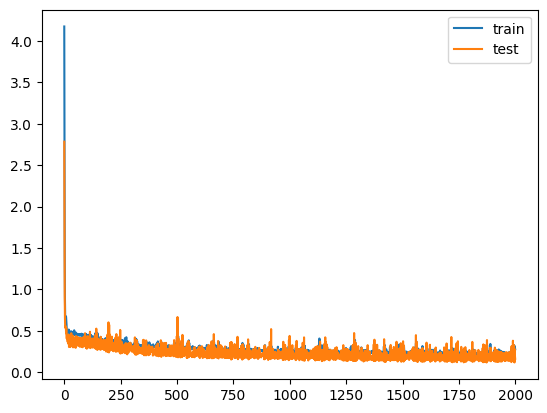

In [11]:
plt.plot(history2.history['loss'],label ='train')
plt.plot(history2.history['val_loss'],label = 'test')
plt.legend()

In [12]:
model1.get_weights()[0].shape

(2, 128)

In [13]:
 model1_weight_layer1 = model1.get_weights()[0].reshape(256)
 model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

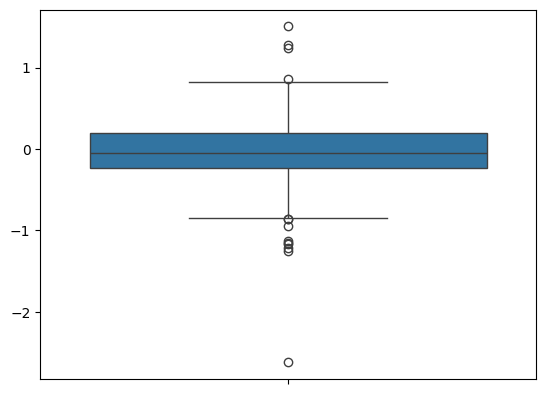

In [14]:
sns.boxplot(model1_weight_layer1)

<Axes: >

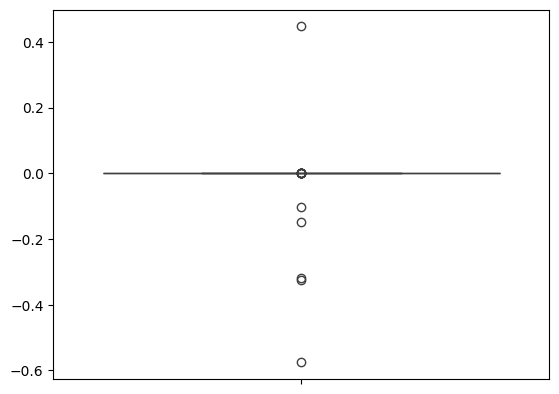

In [15]:
sns.boxplot(model2_weight_layer1)


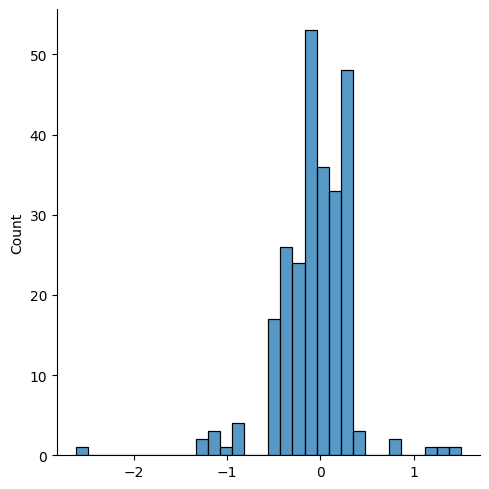

In [16]:
sns.displot(model1_weight_layer1)